In [1]:
from typing import TypedDict, List
from langchain_ollama import OllamaLLM, OllamaEmbeddings
from langchain_community.vectorstores import Chroma
from langgraph.graph import StateGraph, END

In [2]:
from typing import TypedDict, List
from langchain_ollama import OllamaLLM, OllamaEmbeddings
from langchain_community.vectorstores import Chroma
from langgraph.graph import StateGraph, END

In [3]:
# This is the "memory" passed between every node in the graph

class AgentState(TypedDict):
    question: str                  # the user's question
    retrieved_context: List[dict]  # chunks retrieved from ChromaDB
    answer: str                    # the final generated answer

In [4]:
# Load the same embeddings model used during indexing
embeddings = OllamaEmbeddings(model="nomic-embed-text")

# Connect to the ChromaDB we built in setup_pipeline.ipynb
vectorstore = Chroma(
    persist_directory="./chroma_db",
    embedding_function=embeddings
)

# Load the text LLM for answering questions
llm = OllamaLLM(model="llama3.2")

print("Vectorstore and LLM loaded")

/var/folders/qd/k_nxlhp161gdwfh2kvvsftl80000gn/T/ipykernel_55227/3648923400.py:5: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vectorstore = Chroma(


Vectorstore and LLM loaded


In [5]:
def retrieve_context(state: AgentState) -> AgentState:
    """
    Node 1: Takes the user question, searches ChromaDB,
    and returns the top-k most relevant chunks.
    """
    print("🔍 Retrieving context...")

    results = vectorstore.similarity_search(state["question"], k=6)

    context = [
        {
            "content": doc.page_content,
            "timestamp": doc.metadata.get("timestamp", "N/A"),
            "modality": doc.metadata.get("modality", "text")
        }
        for doc in results
    ]

    return {**state, "retrieved_context": context}

In [6]:
def generate_answer(state: AgentState) -> AgentState:
    """
    Node 2: Takes the retrieved context and the question,
    builds a prompt, and generates a final answer using the LLM.
    """
    print("Generating answer...")

    # Format retrieved chunks into readable context string
    context_str = ""
    for i, chunk in enumerate(state["retrieved_context"]):
        context_str += (
            f"\n[{i+1}] [{chunk['modality'].upper()} @ {chunk['timestamp']}]\n"
            f"{chunk['content']}\n"
        )

    prompt = f"""You are a video understanding assistant. Answer the user's question using ONLY the context below.

Context from the video:
{context_str}

User Question: {state['question']}

Instructions:
- Provide a clear answer using the context
- Reference timestamps where relevant (e.g., "At 02:15, ...")
- If the answer involves visuals, mention what is shown
- If the context is insufficient, say so honestly

### Answer
<your answer here>

### ⏱ Relevant Timestamps
<list timestamps used>

### Explanation
<brief reasoning>
"""

    answer = llm.invoke(prompt)
    return {**state, "answer": answer}

In [7]:
def build_graph():
    graph = StateGraph(AgentState)

    # Register nodes
    graph.add_node("retrieve", retrieve_context)
    graph.add_node("answer", generate_answer)

    # Define the flow
    graph.set_entry_point("retrieve")
    graph.add_edge("retrieve", "answer")
    graph.add_edge("answer", END)

    return graph.compile()

agent = build_graph()
print("LangGraph agent compiled")

LangGraph agent compiled


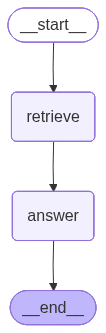

In [8]:
from IPython.display import Image as IPImage, display

try:
    graph_image = agent.get_graph().draw_mermaid_png()
    display(IPImage(graph_image))
except Exception as e:
    print(f"Could not render graph image: {e}")
    print(agent.get_graph().draw_mermaid())  # fallback: print mermaid text

In [9]:

question = "What is the main topic of the video?"

result = agent.invoke({
    "question": question,
    "retrieved_context": [],
    "answer": ""
})

print(result["answer"])
print("\n⏱ Sources used:")
for chunk in result["retrieved_context"]:
    print(f"  [{chunk['modality']}] @ {chunk['timestamp']}")

🔍 Retrieving context...
Generating answer...
The main topic of the video appears to be improving one's English skills. 

⏱ Relevant Timestamps:
[1] 05:07, [2] 19:39, [3] 10:30 (image with a microphone and people discussing)

Explanation:
The context suggests that the video is focused on learning or improving English, as seen in image [3], where two individuals are engaged in an activity requiring audio equipment, including a microphone. The text "Even before your English" also implies that the content may relate to language learning.

⏱ Sources used:
  [text] @ 05:07
  [text] @ 19:39
  [image] @ 10:30
  [text] @ 25:33
  [image] @ 25:30
  [text] @ 19:20


In [10]:


print("🎬 Video Q&A Agent Ready! (type 'quit' to exit)\n")

while True:
    question = input("❓ Your question: ").strip()

    if question.lower() in ["quit", "exit", "q"]:
        print("👋 Exiting. Goodbye!")
        break
    if not question:
        continue

    result = agent.invoke({
        "question": question,
        "retrieved_context": [],
        "answer": ""
    })

    print("\n" + "=" * 60)
    print(result["answer"])
    print("\n⏱ Sources used:")
    for chunk in result["retrieved_context"]:
        print(f"  [{chunk['modality']}] @ {chunk['timestamp']}")
    print("=" * 60 + "\n")

🎬 Video Q&A Agent Ready! (type 'quit' to exit)

👋 Exiting. Goodbye!
